In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

In [ ]:
df = pd.read_csv("C:/Users/mondal/Downloads/Synthetic.csv") #Sir please change this to your own path
df.head()

,Unnamed: 0,X,Y
0,0,37.454012,126.746701
1,1,95.071431,293.927975
2,2,73.199394,225.441700
3,3,59.865848,183.586508
4,4,15.601864,39.020372


In [53]:
def Data_Prep(df):
    x = df.iloc[:, 1].values
    y = df.iloc[:, 2].values

    x = (x - np.mean(x)) / np.std(x)
    x = x.reshape(1, -1)
    y = y.reshape(-1, 1)

    return x, y

In [54]:
x = Data_Prep(df)[0]
y = Data_Prep(df)[1]
m = x.shape[1]

In [55]:
#For all three gradient descent methods: 
# The learning rate is set to 0.0001, the number of epochs is set to 10000, and the tolerance is set to 0.001. 
# The batch size for mini-batch gradient descent is set to 10.

In [56]:
def Batch_Gradient(l_rate, Epochs, Tol):
    epoch = 1
    loss = 1
    epoch_loss = []

    theta_0 = np.array(np.random.randn()).reshape(1,1)
    theta_1 = np.array(np.random.randn()).reshape(1,1)

    while epoch <= Epochs and loss > Tol:
        y_hat = theta_0*x + theta_1
        error = y_hat.T - y
        loss = 1/2 * np.mean(error**2)
        d_t0 = 1/m*np.dot(x,error)
        d_t1 = 1/m*np.sum(error)
        theta_0 = theta_0 - l_rate * d_t0
        theta_1 = theta_1 - l_rate * d_t1
        epoch_loss.append(loss)
        epoch += 1

    return epoch_loss

Maximum loss: 13600.987148629412 
Minimum loss: 1876.4610046124685


Text(0.5, 1.0, 'Batch Gradient Descent')

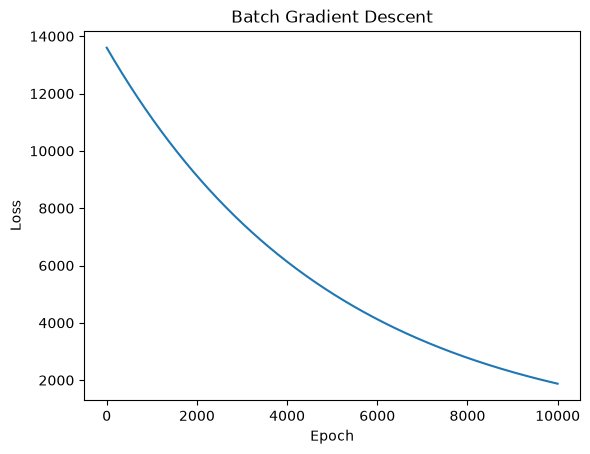

In [57]:
output = Batch_Gradient(0.0001,10000,0.001)
print("Maximum loss:", max(output),"\nMinimum loss:", min(output))

plt.plot(output)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Batch Gradient Descent")


In [58]:
def Stochastic_Gradient(l_rate, Epochs, Tol):
    indices = list(range(m))
    epoch = 1
    mean_epoch_loss = 1
    epoch_loss = []

    theta_0 = np.array(np.random.randn())
    theta_1 = np.array(np.random.randn())

    while epoch <= Epochs and mean_epoch_loss > Tol:
        
        step_loss = []
        rand_ind = random.sample(indices,len(indices))
        
        for i in rand_ind:

            xi = x[0,i]
            yi = y[i,0]
            
            y_hat = theta_0*xi + theta_1
            loss = y_hat-yi
            step_loss.append(loss**2)

            d_t0 = 2*(xi*loss)
            d_t1 = 2*loss

            theta_0 = theta_0 - l_rate * d_t0
            theta_1 = theta_1 - l_rate * d_t1

        mean_epoch_loss = np.mean(step_loss)
        epoch_loss.append(mean_epoch_loss)
        epoch += 1

    return(epoch_loss)
         

Maximum loss: 26242.150901355595 
Minimum loss: 82.34548793313714


Text(0.5, 1.0, 'Stochastic Gradient Descent')

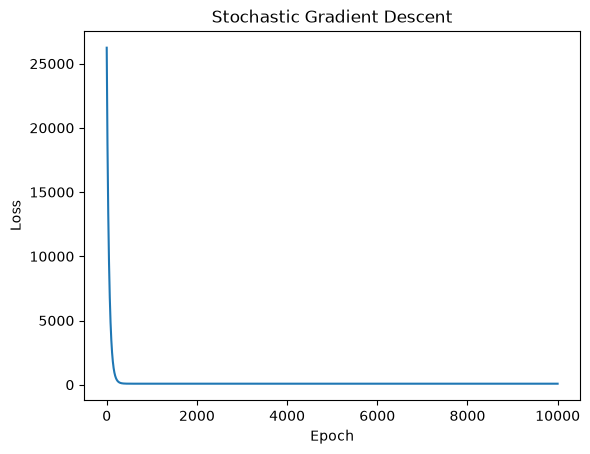

In [59]:
output = Stochastic_Gradient(0.0001,10000,0.001)
print("Maximum loss:", max(output),"\nMinimum loss:", min(output))

plt.plot(output)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Stochastic Gradient Descent")

In [60]:
def Mini_Batch_Gradient(l_rate, Epochs, Tol, batch_size):
    indices = list(range(m))
    epoch = 1
    mean_epoch_loss = 1
    epoch_loss = []

    theta_0 = np.array(np.random.randn()).reshape(1,1)
    theta_1 = np.array(np.random.randn()).reshape(1,1)

    while epoch <= Epochs and mean_epoch_loss > Tol:
        
        batch_loss = []
        rand_ind = random.sample(indices, len(indices))

        i = 0
        while(i < m):

            xi = x[:,rand_ind[i:i+batch_size]]
            yi = y[rand_ind[i:i+batch_size],:]

            y_hat = theta_0*xi + theta_1
            error = y_hat.T - yi
            loss = 1/2 * np.mean(error**2)
            batch_loss.append(loss)

            d_t0 = 1/batch_size*np.dot(xi,error)
            d_t1 = 1/batch_size*np.sum(error)
            theta_0 = theta_0 - l_rate * d_t0
            theta_1 = theta_1 - l_rate * d_t1

            i += batch_size

        mean_epoch_loss = np.mean(batch_loss)
        epoch_loss.append(mean_epoch_loss)
        epoch += 1

    return(epoch_loss)

Maximum loss: 13622.189651755005 
Minimum loss: 41.77144804740263


Text(0.5, 1.0, 'Mini-Batch Gradient Descent')

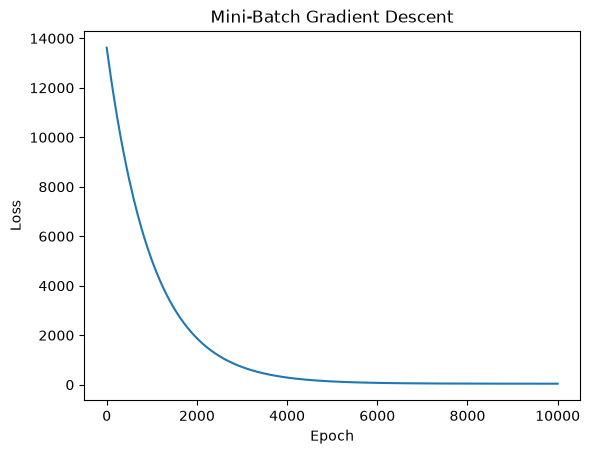

In [61]:
output = Mini_Batch_Gradient(0.0001,10000,0.001,10)
print("Maximum loss:", max(output),"\nMinimum loss:", min(output))

plt.plot(output)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Mini-Batch Gradient Descent")